In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import random
import types

import numpy as np

import torch
import torch.nn as nn

from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plot

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))

Device:  cuda
GPU:  Tesla T4


In [ ]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
def forward_without_skip(self, x):

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)
    out = self.relu(out)

    return out

In [ ]:
weights = ResNet152_Weights.DEFAULT
modified_model = resnet152(weights = weights)

for parameter in modified_model.parameters():
    parameter.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 189MB/s]


In [ ]:
selected_blocks = [modified_model.layer2[-1],
                   modified_model.layer3[-1],
                   modified_model.layer4[-1]
                  ]
#! randomly chose some blocks and avoid residual connection
for block in selected_blocks:
    block.forward = types.MethodType(forward_without_skip, block)

In [ ]:
number_of_features = modified_model.fc.in_features

modified_model.fc = nn.Linear(number_of_features, len(classes))
modified_model = modified_model.to(device)

print(modified_model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modified_model.fc.parameters(), lr = 0.001)

In [ ]:
transform = weights.transforms()

DATA_PATH = "/content/drive/MyDrive/ATML/data"

full_train_dataset = datasets.CIFAR10(
    root=DATA_PATH,
    train=True,
    download=False,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=generator
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [ ]:
EPOCHS = 5
skip_training_losses = []
skip_validation_losses = []

skip_training_accuracies = []
skip_validation_accuracies = []

for epoch in range(EPOCHS):
    modified_model.eval()
    modified_model.fc.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() #! clear gradients
        outputs = modified_model(images) #! model's prediction
        batch_loss = loss(outputs, labels) #! loss
        batch_loss.backward() #! backpropogate
        optimizer.step() #! update the weights

        running_loss += batch_loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)

        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    training_accuracy = (correct_predictions / total_predictions) * 100
    average_training_loss = (running_loss / total_predictions)

    modified_model.eval()

    validation_running_loss = 0.0
    validation_correct_predictions = 0
    validation_total_predictions = 0

    with torch.no_grad():

        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = modified_model(images)

            validation_running_loss += loss(outputs, labels).item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            validation_total_predictions += labels.size(0)

            validation_correct_predictions += (predicted == labels).sum().item()

    validation_accuracy = (validation_correct_predictions / validation_total_predictions) * 100
    average_validation_loss = (validation_running_loss) / validation_total_predictions

    skip_training_losses.append(average_training_loss)
    skip_training_accuracies.append(training_accuracy)
    skip_validation_losses.append(average_validation_loss)
    skip_validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Training Loss: {average_training_loss:.4f} | "
        f"Training Accuracy: {training_accuracy:.2f}% | "
        f"Validation Loss: {average_validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.2f}%"
    )

Epoch 1/5 | Training Loss: 2.2734 | Training Accuracy: 17.25% | Validation Loss: 2.2449 | Validation Accuracy: 22.22%
Epoch 2/5 | Training Loss: 2.2257 | Training Accuracy: 21.80% | Validation Loss: 2.2063 | Validation Accuracy: 23.97%
Epoch 3/5 | Training Loss: 2.1926 | Training Accuracy: 23.23% | Validation Loss: 2.1805 | Validation Accuracy: 22.77%
Epoch 4/5 | Training Loss: 2.1683 | Training Accuracy: 24.18% | Validation Loss: 2.1577 | Validation Accuracy: 23.76%
Epoch 5/5 | Training Loss: 2.1495 | Training Accuracy: 24.88% | Validation Loss: 2.1385 | Validation Accuracy: 25.60%


In [ ]:
np.savez(
    "/content/drive/MyDrive/ATML/skip_metrics.npz",
    training_losses=skip_training_losses,
    validation_losses=skip_validation_losses,
    training_accuracies=skip_training_accuracies,
    validation_accuracies=skip_validation_accuracies
)

print("Skip-connection metrics saved.")

Skip-connection metrics saved.


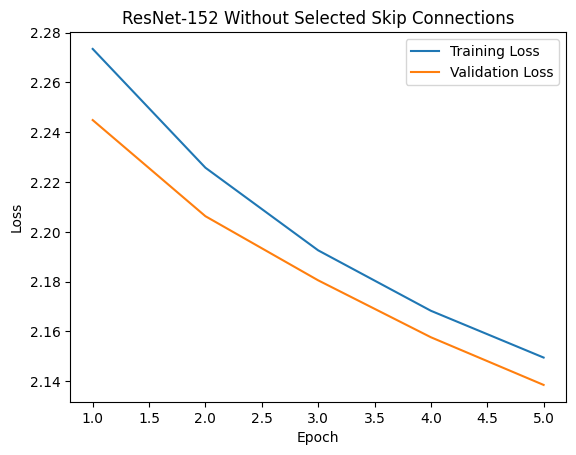

In [ ]:
epochs = range(1, EPOCHS + 1)

plot.figure()

plot.plot(
    epochs,
    skip_training_losses,
    label="Training Loss"
)

plot.plot(
    epochs,
    skip_validation_losses,
    label="Validation Loss"
)

plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.title(
    "ResNet-152 Without Selected Skip Connections"
)
plot.legend()

plot.show()

In [ ]:
baseline_metrics = np.load(
    "/content/drive/MyDrive/ATML/baseline_metrics.npz"
)

baseline_training_losses = baseline_metrics["training_losses"]
baseline_validation_losses = baseline_metrics["validation_losses"]
baseline_training_accuracies = baseline_metrics["training_accuracies"]
baseline_validation_accuracies = baseline_metrics["validation_accuracies"]

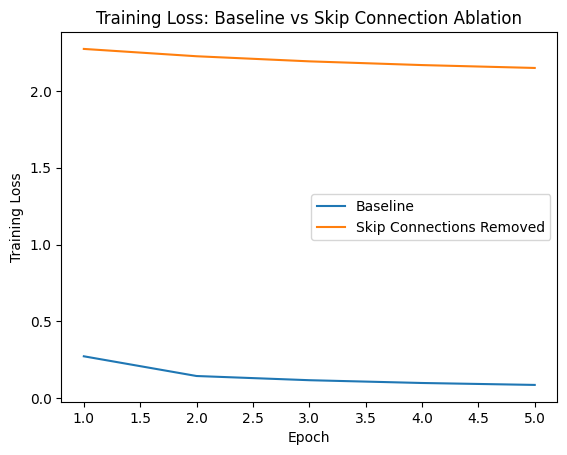

In [ ]:
epochs = range(1, EPOCHS + 1)

plot.figure()

plot.plot(
    epochs,
    baseline_training_losses,
    label="Baseline"
)

plot.plot(
    epochs,
    skip_training_losses,
    label="Skip Connections Removed"
)

plot.xlabel("Epoch")
plot.ylabel("Training Loss")
plot.title("Training Loss: Baseline vs Skip Connection Ablation")
plot.legend()

plot.show()

In [ ]:
print(
    "Best Baseline Validation Accuracy:",
    f"{max(baseline_validation_accuracies):.2f}%"
)

print(
    "Best Skip-Ablation Validation Accuracy:",
    f"{max(skip_validation_accuracies):.2f}%"
)

accuracy_drop = (
    max(baseline_validation_accuracies)
    - max(skip_validation_accuracies)
)

print(
    "Validation Accuracy Drop:",
    f"{accuracy_drop:.2f} percentage points"
)

Best Baseline Validation Accuracy: 95.02%
Best Skip-Ablation Validation Accuracy: 25.60%
Validation Accuracy Drop: 69.42 percentage points
